# HIV Hi — Model complexity plots

This notebook visualizes how model complexity changes when hyperparameters are selected with:

- OOD holdout
- random shuffle

The goal is to connect:

- selected hyperparameters
- model complexity
- train-validation-test gaps
- final OOD generalization

In [9]:
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
 
PROJECT_ROOT = Path("../..").resolve()
 
DATA_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / "hi"
    / "hiv"
)
 
FIG_DIR = DATA_DIR / "figures_complexity"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
complexity_all = pd.read_csv(DATA_DIR / "complexity_all.csv")
dt_table = pd.read_csv(DATA_DIR / "complexity_dt.csv")
lr_table = pd.read_csv(DATA_DIR / "complexity_lr.csv")
svm_table = pd.read_csv(DATA_DIR / "complexity_svm.csv")
gap_analysis = pd.read_csv(DATA_DIR / "complexity_gap_analysis.csv")

In [11]:
PROTOCOL_COLORS = {
    "OOD holdout": "#2563EB",
    "Random shuffle": "#DC2626",
}
 
FP_MARKERS = {
    "ECFP4": "o",
    "MACCS": "s",
    "RDKit desc": "D",
}
 
FP_LINESTYLES = {
    "ECFP4": "-",
    "MACCS": "--",
    "RDKit desc": ":",
}
 
def _strip_plot(ax, data, x_col, y_col, group_col, color_map, jitter_width=0.15):
    """
    Draw a strip plot with individual fold points + elegant mean horizontal line.
    """
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    cat_to_x = dict(zip(categories, x_positions))
 
    for _, row in data.iterrows():
        x_base = cat_to_x[row[x_col]]
        jitter = (row["fold"] - 2) * jitter_width  
        color = color_map[row[group_col]]
 
        ax.scatter(
            x_base + jitter,
            row[y_col],
            c=color,
            s=65,             
            alpha=0.8,        
            edgecolors="black", 
            linewidths=0.5,
            zorder=3,
        )
 
    for cat in categories:
        x_base = cat_to_x[cat]
        for protocol in data[group_col].unique():
            mask = (data[x_col] == cat) & (data[group_col] == protocol)
            if mask.sum() == 0:
                continue
            mean_val = data.loc[mask, y_col].mean()
            color = color_map[protocol]
            
            ax.hlines(
                mean_val,
                xmin=x_base - 0.20,
                xmax=x_base + 0.20,
                colors=color,
                linewidths=2.0,    
                alpha=0.85,      
                zorder=4,
            )
 
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, rotation=15, ha="right", fontsize=10, weight='medium')

# Complexity by protocol

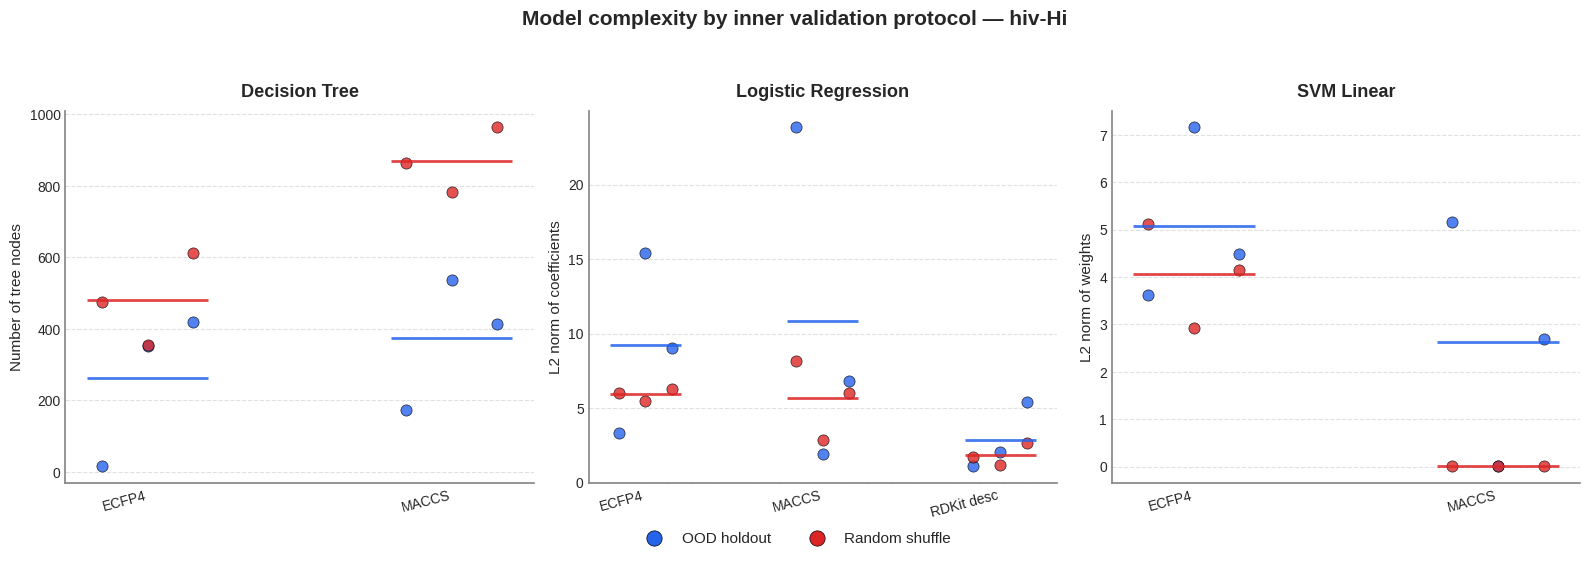

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Decision Tree ---
dt_plot = dt_table.copy()
dt_plot["fp_label"] = dt_plot["fingerprint"]
_strip_plot(axes[0], dt_plot, "fp_label", "n_nodes", "protocol", PROTOCOL_COLORS)
axes[0].set_ylabel("Number of tree nodes", fontsize=11, weight='medium')
axes[0].set_title("Decision Tree", fontsize=13, fontweight="bold", pad=10)


# --- Logistic Regression ---
lr_plot = lr_table.copy()
lr_plot["fp_label"] = lr_plot["fingerprint"]
_strip_plot(axes[1], lr_plot, "fp_label", "l2_norm", "protocol", PROTOCOL_COLORS)
axes[1].set_ylabel("L2 norm of coefficients", fontsize=11, weight='medium')
axes[1].set_title("Logistic Regression", fontsize=13, fontweight="bold", pad=10)

# --- SVM Linear ---
svm_plot = svm_table.copy()
svm_plot["fp_label"] = svm_plot["fingerprint"]
_strip_plot(axes[2], svm_plot, "fp_label", "l2_norm", "protocol", PROTOCOL_COLORS)
axes[2].set_ylabel("L2 norm of weights", fontsize=11, weight='medium')
axes[2].set_title("SVM Linear", fontsize=13, fontweight="bold", pad=10)


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle='--', color='lightgrey', alpha=0.7)
    
    ax.tick_params(axis='x', rotation=15, labelsize=10, color='#888888')
    ax.tick_params(axis='y', labelsize=10, color='#888888')
    
    ax.set_xlabel("") 


legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
           markersize=11, markeredgecolor='black', markeredgewidth=0.5, label=p)
    for p, c in PROTOCOL_COLORS.items()
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.05),
    frameon=False 
)
 
fig.suptitle(
    "Model complexity by inner validation protocol — hiv-Hi",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
 
plt.subplots_adjust(wspace=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_complexity_by_protocol_panel.png", dpi=300, bbox_inches="tight")
plt.show()

# Complexity vs optimism gap

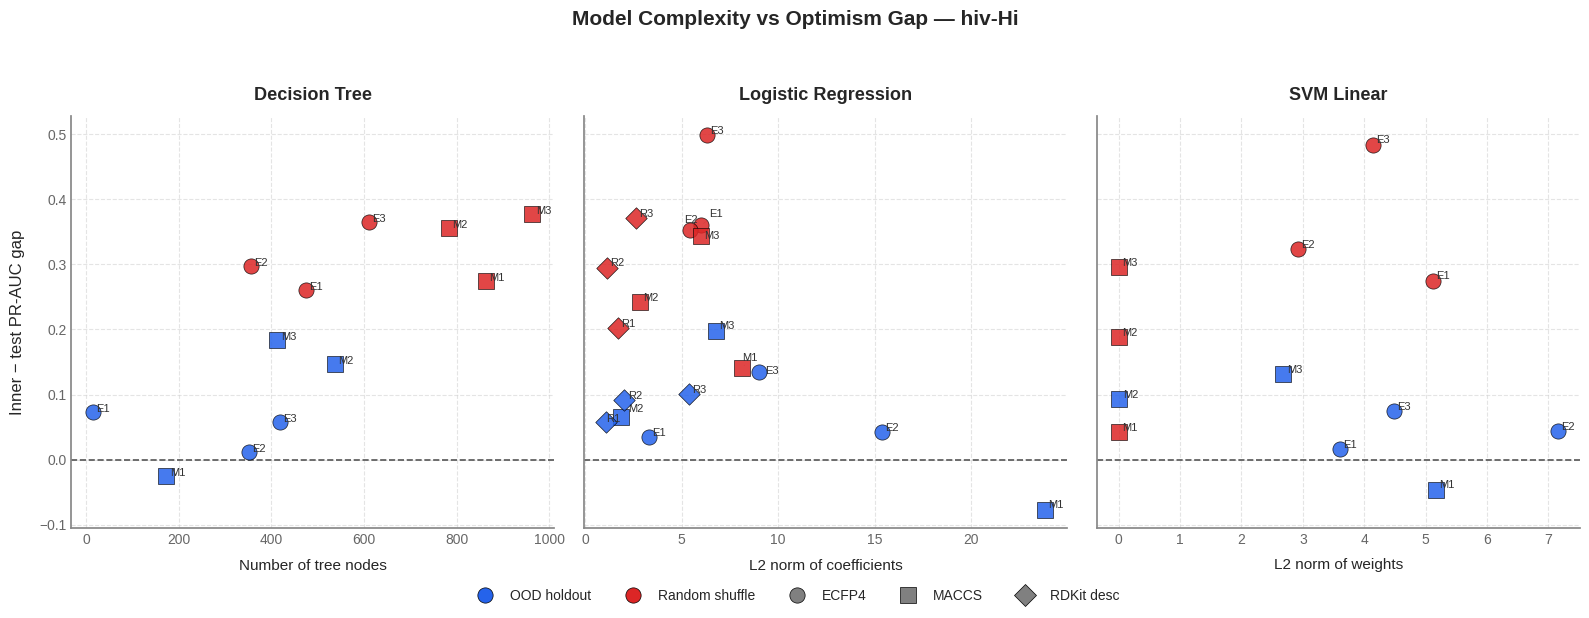

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
 
panel_config = [
    (axes[0], dt_table, "n_nodes", "Number of tree nodes", "Decision Tree"),
    (axes[1], lr_table, "l2_norm", "L2 norm of coefficients", "Logistic Regression"),
    (axes[2], svm_table, "l2_norm", "L2 norm of weights", "SVM Linear"),
]
 
for ax, df, x_col, x_label, title in panel_config:
    texts = [] 
    
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.6, zorder=0)
    
    ax.axhline(0, linewidth=1.2, color="#555555", linestyle="--", zorder=1)
    
    for _, row in df.iterrows():
        protocol = row["protocol"]
        fp = row["fingerprint"]
        color = PROTOCOL_COLORS[protocol]
        marker = FP_MARKERS.get(fp, "o")
 
        ax.scatter(
            row[x_col],
            row["inner_test_gap"],
            c=color,
            marker=marker,
            s=120, 
            edgecolors="black", 
            alpha=0.85,
            linewidths=0.5,
            zorder=3,
        )
 
        fp_short = fp[0] if fp != "RDKit desc" else "R"
        label_text = f"{fp_short}{int(row['fold'])}"
        
        txt = ax.text(
            row[x_col], 
            row["inner_test_gap"], 
            label_text, 
            fontsize=8, 
            color='#333333'
        )
        texts.append(txt)
    
    adjust_text(
        texts, 
        ax=ax,
        arrowprops=dict(arrowstyle="-", color='grey', lw=0.5, alpha=0.5)
    )
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    ax.tick_params(colors='#666666')
    
    ax.set_xlabel(x_label, fontsize=11, weight='medium', labelpad=8)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
 
axes[0].set_ylabel("Inner − test PR-AUC gap", fontsize=12, weight='medium', labelpad=10)
 
protocol_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
           markersize=11, markeredgecolor='black', markeredgewidth=0.5, label=p)
    for p, c in PROTOCOL_COLORS.items()
]
fp_handles = [
    Line2D([0], [0], marker=m, color="w", markerfacecolor="grey",
           markersize=11, markeredgecolor='black', markeredgewidth=0.5, label=name)
    for name, m in FP_MARKERS.items()
]
 
fig.legend(
    handles=protocol_handles + fp_handles,
    loc="lower center",
    ncol=5,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.05),
    frameon=False 
)
 
fig.suptitle(
    "Model Complexity vs Optimism Gap — hiv-Hi",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
 
plt.tight_layout()
plt.savefig(FIG_DIR / "02_complexity_vs_gap_panel.png", dpi=300, bbox_inches="tight")
plt.show()

# Train / inner / test PR-AUC profile

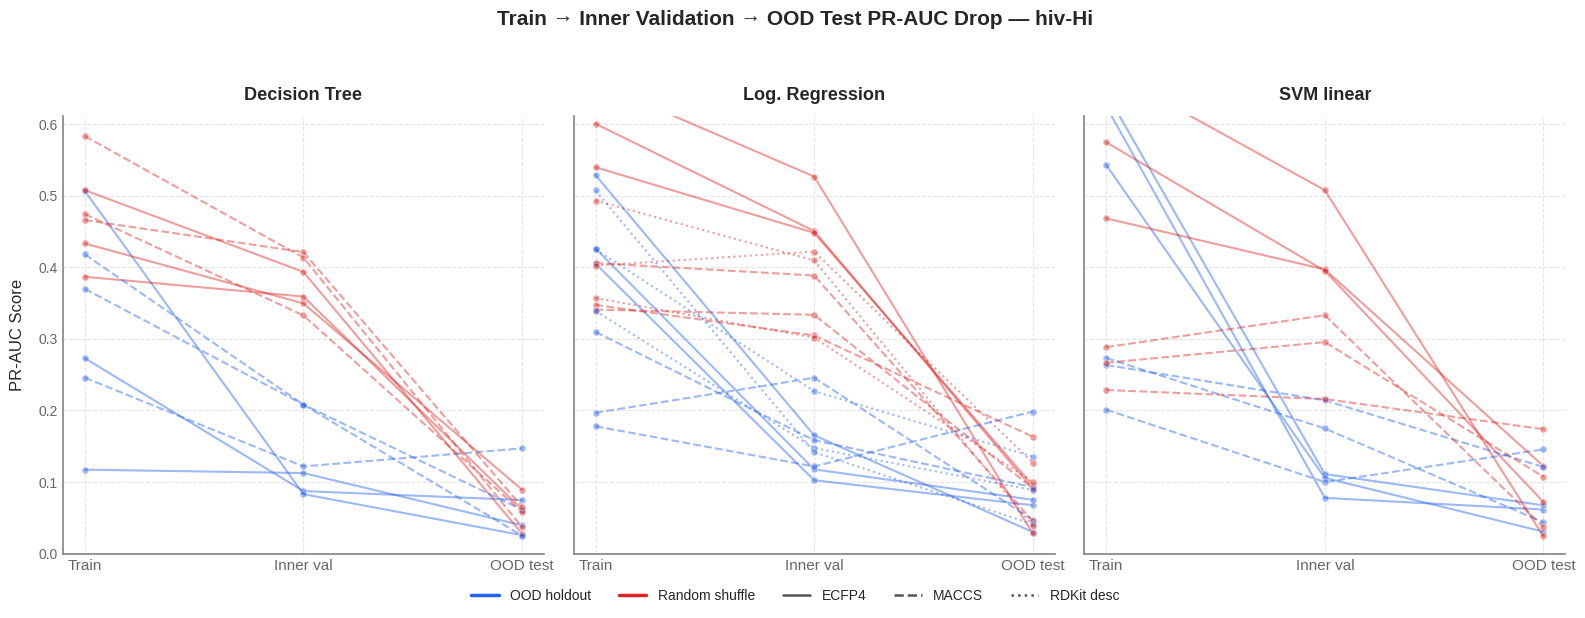

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
 
models = gap_analysis["model"].unique()
stage_labels = ["Train", "Inner val", "OOD test"]
stage_cols = ["train_pr_auc", "inner_pr_auc", "test_pr_auc"]
x_stage = np.arange(len(stage_labels))
 
for ax, model in zip(axes, models):
    sub_model = gap_analysis[gap_analysis["model"] == model]
 
    
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.6, zorder=0)

    for _, row in sub_model.iterrows():
        protocol = row["protocol"]
        fp = row["fingerprint"]
 
        color = PROTOCOL_COLORS[protocol]
        ls = FP_LINESTYLES.get(fp, "-")
 
        y_values = [row[col] for col in stage_cols]
 
        ax.plot(
            x_stage,
            y_values,
            color=color,
            linestyle=ls,
            linewidth=1.5,     
            alpha=0.45,        
            marker="o",
            markersize=5,
            markeredgecolor='white', 
            markeredgewidth=0.8,
            zorder=3
        )
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    ax.tick_params(colors='#666666')

    ax.set_xticks(x_stage)
    ax.set_xticklabels(stage_labels, fontsize=11, weight='medium')
    ax.set_title(
        model.replace("Logistic Regression", "Log. Regression"),
        fontsize=13,
        fontweight="bold",
        pad=12
    )
    ax.set_ylim(bottom=0.0)
 
axes[0].set_ylabel("PR-AUC Score", fontsize=12, weight='medium', labelpad=10)
 
protocol_handles = [
    Line2D([0], [0], color=c, linewidth=2.5, label=p)
    for p, c in PROTOCOL_COLORS.items()
]
fp_handles = [
    Line2D([0], [0], color="#555555", linestyle=ls, linewidth=1.8, label=name) 
    for name, ls in FP_LINESTYLES.items()
]
 
fig.legend(
    handles=protocol_handles + fp_handles,
    loc="lower center",
    ncol=5,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.05),
    frameon=False
)
 
fig.suptitle(
    "Train → Inner Validation → OOD Test PR-AUC Drop — hiv-Hi",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)
 
plt.subplots_adjust(wspace=0.15) 
plt.tight_layout()
plt.savefig(FIG_DIR / "03_train_inner_test_profile_panel.png", dpi=300, bbox_inches="tight")
plt.show()

# Selected hyperparameters heatmap

/tmp/ipykernel_4108479/2732210674.py:178: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_4108479/2732210674.py:179: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig(FIG_DIR / "04_hyperparameters_heatmap.png", dpi=300, bbox_inches="tight")
/home/f.capria/miniconda3/envs/lohi/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


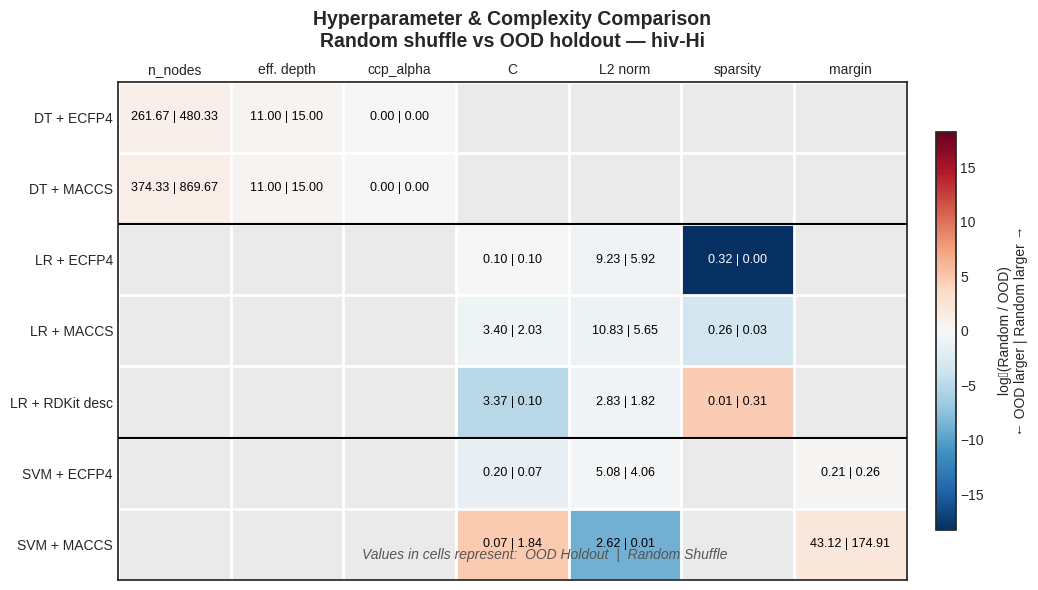

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

dt_summary = (
    dt_table
    .groupby(["fingerprint", "protocol"])
    .agg(
        ccp_alpha_mean=("ccp_alpha", "mean"),
        n_nodes_mean=("n_nodes", "mean"),
        effective_depth_mean=("effective_depth", "mean"),
        n_features_used_mean=("n_features_used", "mean"),
    )
    .reset_index()
)
 
lr_summary = (
    lr_table
    .groupby(["fingerprint", "protocol"])
    .agg(
        C_mean=("C", "mean"),
        l2_norm_mean=("l2_norm", "mean"),
        n_nonzero_mean=("n_nonzero_coefficients", "mean"),
        sparsity_mean=("sparsity", "mean"),
    )
    .reset_index()
)
 
svm_summary = (
    svm_table
    .groupby(["fingerprint", "protocol"])
    .agg(
        C_mean=("C", "mean"),
        l2_norm_mean=("l2_norm", "mean"),
        approx_margin_mean=("approx_margin", "mean"),
    )
    .reset_index()
)
 
rows_for_heatmap = []
 
# DT
for fp in dt_summary["fingerprint"].unique():
    ood = dt_summary[(dt_summary["fingerprint"] == fp) & (dt_summary["protocol"] == "OOD holdout")]
    rnd = dt_summary[(dt_summary["fingerprint"] == fp) & (dt_summary["protocol"] == "Random shuffle")]
    if len(ood) == 0 or len(rnd) == 0:
        continue
    ood, rnd = ood.iloc[0], rnd.iloc[0]
    rows_for_heatmap.extend([
        {"experiment": f"DT + {fp}", "metric": "n_nodes", "OOD holdout": ood["n_nodes_mean"], "Random shuffle": rnd["n_nodes_mean"]},
        {"experiment": f"DT + {fp}", "metric": "eff. depth", "OOD holdout": ood["effective_depth_mean"], "Random shuffle": rnd["effective_depth_mean"]},
        {"experiment": f"DT + {fp}", "metric": "ccp_alpha", "OOD holdout": ood["ccp_alpha_mean"], "Random shuffle": rnd["ccp_alpha_mean"]}
    ])
 
# LR
for fp in lr_summary["fingerprint"].unique():
    ood = lr_summary[(lr_summary["fingerprint"] == fp) & (lr_summary["protocol"] == "OOD holdout")]
    rnd = lr_summary[(lr_summary["fingerprint"] == fp) & (lr_summary["protocol"] == "Random shuffle")]
    if len(ood) == 0 or len(rnd) == 0:
        continue
    ood, rnd = ood.iloc[0], rnd.iloc[0]
    rows_for_heatmap.extend([
        {"experiment": f"LR + {fp}", "metric": "C", "OOD holdout": ood["C_mean"], "Random shuffle": rnd["C_mean"]},
        {"experiment": f"LR + {fp}", "metric": "L2 norm", "OOD holdout": ood["l2_norm_mean"], "Random shuffle": rnd["l2_norm_mean"]},
        {"experiment": f"LR + {fp}", "metric": "sparsity", "OOD holdout": ood["sparsity_mean"], "Random shuffle": rnd["sparsity_mean"]}
    ])
 
# SVM
for fp in svm_summary["fingerprint"].unique():
    ood = svm_summary[(svm_summary["fingerprint"] == fp) & (svm_summary["protocol"] == "OOD holdout")]
    rnd = svm_summary[(svm_summary["fingerprint"] == fp) & (svm_summary["protocol"] == "Random shuffle")]
    if len(ood) == 0 or len(rnd) == 0:
        continue
    ood, rnd = ood.iloc[0], rnd.iloc[0]
    rows_for_heatmap.extend([
        {"experiment": f"SVM + {fp}", "metric": "C", "OOD holdout": ood["C_mean"], "Random shuffle": rnd["C_mean"]},
        {"experiment": f"SVM + {fp}", "metric": "L2 norm", "OOD holdout": ood["l2_norm_mean"], "Random shuffle": rnd["l2_norm_mean"]},
        {"experiment": f"SVM + {fp}", "metric": "margin", "OOD holdout": ood["approx_margin_mean"], "Random shuffle": rnd["approx_margin_mean"]}
    ])
 
hp_df = pd.DataFrame(rows_for_heatmap)

hp_df["ood_safe"] = hp_df["OOD holdout"].replace(0, 1e-6)
hp_df["rnd_safe"] = hp_df["Random shuffle"].replace(0, 1e-6)
hp_df["log2_ratio"] = np.log2(hp_df["rnd_safe"] / hp_df["ood_safe"])

mask_zeros = (hp_df["OOD holdout"] < 1e-4) & (hp_df["Random shuffle"] < 1e-4)
hp_df.loc[mask_zeros, "log2_ratio"] = 0.0


pivot_ratio = hp_df.pivot(index="experiment", columns="metric", values="log2_ratio")
pivot_ood = hp_df.pivot(index="experiment", columns="metric", values="OOD holdout")
pivot_rnd = hp_df.pivot(index="experiment", columns="metric", values="Random shuffle")

row_order = [
    "DT + ECFP4", "DT + MACCS", 
    "LR + ECFP4", "LR + MACCS", "LR + RDKit desc", 
    "SVM + ECFP4", "SVM + MACCS"
]
col_order = [
    "n_nodes", "eff. depth", "ccp_alpha", 
    "C", "L2 norm", "sparsity", "margin"
]

row_order = [r for r in row_order if r in pivot_ratio.index]
col_order = [c for c in col_order if c in pivot_ratio.columns]

pivot_ratio = pivot_ratio.loc[row_order, col_order]
pivot_ood = pivot_ood.loc[row_order, col_order]
pivot_rnd = pivot_rnd.loc[row_order, col_order]


fig, ax = plt.subplots(figsize=(11, 6))

vmax = np.nanmax(np.abs(pivot_ratio.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

ax.set_facecolor('#eaeaea')
masked_ratio = np.ma.masked_invalid(pivot_ratio.values)

im = ax.imshow(
    masked_ratio,
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
)

ax.set_yticks(np.arange(len(row_order)))
ax.set_yticklabels(row_order, fontsize=10, weight='medium')
ax.set_xticks(np.arange(len(col_order)))
ax.set_xticklabels(col_order, fontsize=10, weight='medium')
ax.xaxis.tick_top()

for i in range(len(row_order)):
    for j in range(len(col_order)):
        val_ratio = pivot_ratio.iloc[i, j]
        
        if pd.notna(val_ratio):
            ood_val = pivot_ood.iloc[i, j]
            rnd_val = pivot_rnd.iloc[i, j]
            text = f"{ood_val:.2f} | {rnd_val:.2f}"
            
            text_color = "white" if abs(val_ratio) > vmax * 0.55 else "black"
            
            ax.text(
                j, i, text,
                ha="center", va="center",
                fontsize=9, color=text_color,
            )

ax.set_xticks(np.arange(-0.5, len(col_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(which="major", bottom=False, left=False, top=False)

prev_prefix = row_order[0].split(" + ")[0]
for i, row_name in enumerate(row_order):
    current_prefix = row_name.split(" + ")[0]
    if current_prefix != prev_prefix:
        ax.axhline(i - 0.5, color="black", linewidth=1.5, zorder=5)
        prev_prefix = current_prefix

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label("log₂(Random / OOD)\n← OOD larger | Random larger →", fontsize=10, labelpad=10)


ax.set_title(
    "Hyperparameter & Complexity Comparison\nRandom shuffle vs OOD holdout — hiv-Hi",
    fontsize=14,
    fontweight="bold",
    pad=25,
)

fig.text(0.5, 0.06, "Values in cells represent:  OOD Holdout  |  Random Shuffle", ha="center", fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.savefig(FIG_DIR / "04_hyperparameters_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()